In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/online_retail_clean.csv', parse_dates=['InvoiceDate'])

print(df.shape)
df.head()

(779495, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


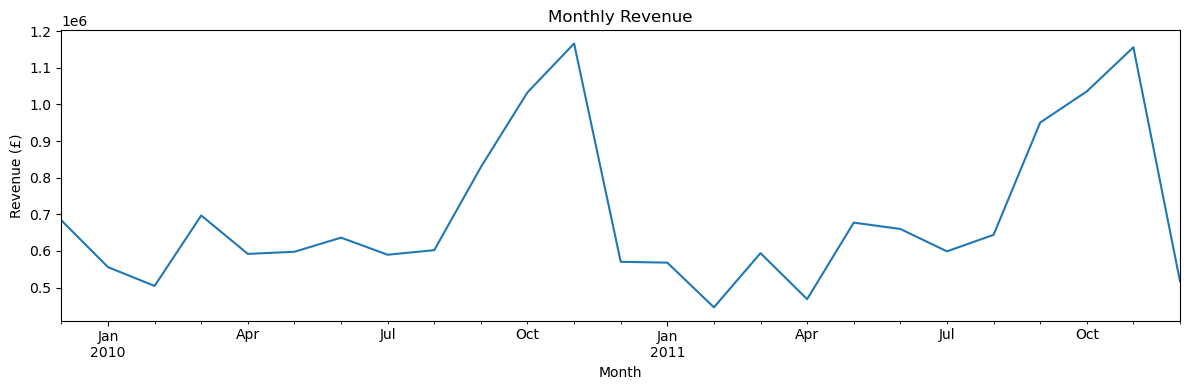

In [ ]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(12, 4))
monthly_revenue.plot()
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


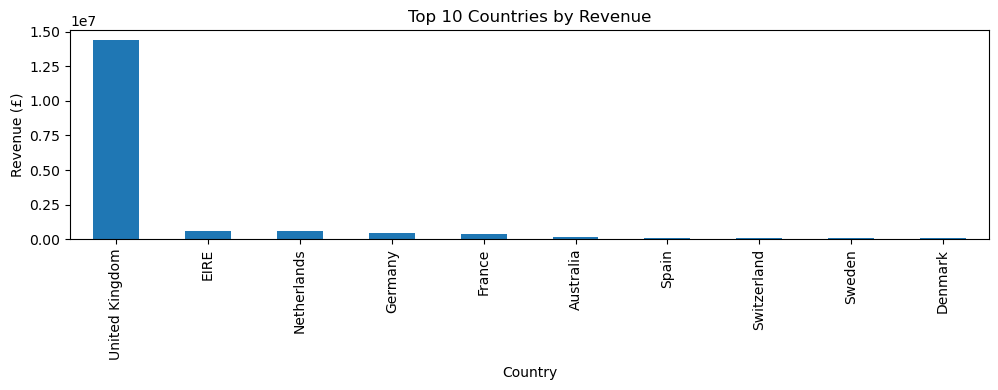

In [3]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


According to the demographics eda and monthly revenue eda, we found out that majority of revenue come from the UK, and there seems like a periodical pattern in monthly revenue which rises at August, peaked at November, and dive down at December.

However, the December drop is likely incomplete data, not a real sales drop — the dataset ends mid-December, so the last month looks artificially low. 



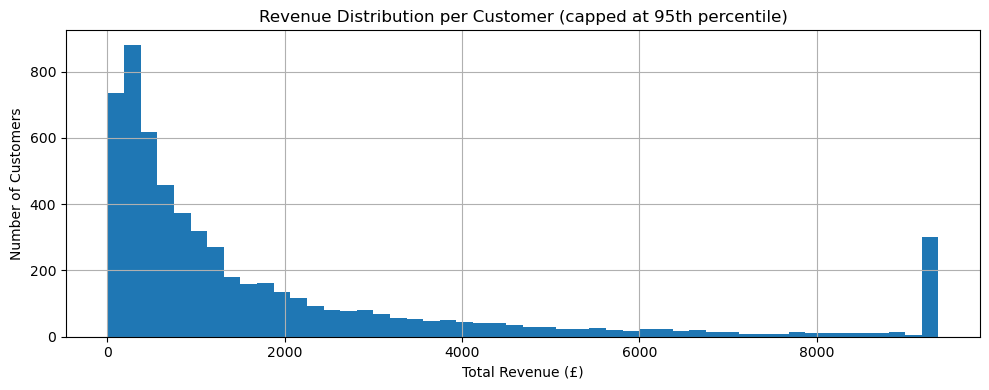

Skewness: 25.08


In [9]:
customer_revenue = df.groupby('Customer ID')['TotalPrice'].sum()

plt.figure(figsize=(10, 4))
customer_revenue.clip(upper=customer_revenue.quantile(0.95)).hist(bins=50)
plt.title('Revenue Distribution per Customer (capped at 95th percentile)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Skewness:", customer_revenue.skew().round(2))


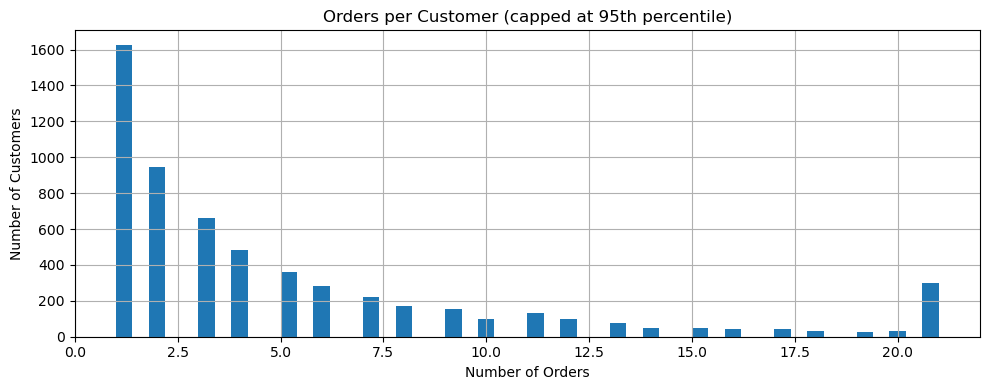

Skewness: 12.65


In [5]:
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique()

plt.figure(figsize=(10, 4))
orders_per_customer.clip(upper=orders_per_customer.quantile(0.95)).hist(bins=50)
plt.title('Orders per Customer (capped at 95th percentile)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Skewness:", orders_per_customer.skew().round(2))


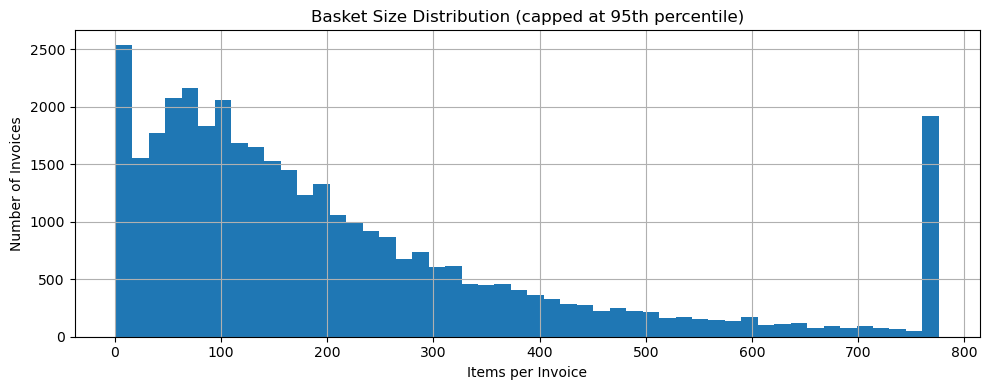

Skewness: 50.31


In [6]:
basket_size = df.groupby('Invoice')['Quantity'].sum()

plt.figure(figsize=(10, 4))
basket_size.clip(upper=basket_size.quantile(0.95)).hist(bins=50)
plt.title('Basket Size Distribution (capped at 95th percentile)')
plt.xlabel('Items per Invoice')
plt.ylabel('Number of Invoices')
plt.tight_layout()
plt.show()

print("Skewness:", basket_size.skew().round(2))


Most customers are low-value, low-frequency buyers. A small  group drives a disproportionate share of orders and revenue. This is  hinting at the future segments — Champions vs. one-time buyers. The EDA are capped for 95%, so the trend is clear, but there are more extreme outliers for the top 5% of revenuend items per order.

All RFM features show extreme right skew (Revenue skewness: 25.08, Frequency skewness: 12.65). K-means relies on Euclidean distance and is highly sensitive to skewed distributions. Basket size skewness of 50.31 confirms the pattern — most invoices contain a small number of items, while a few bulk orders are extreme outliers.  This motivates log transformation in the preprocessing phase.

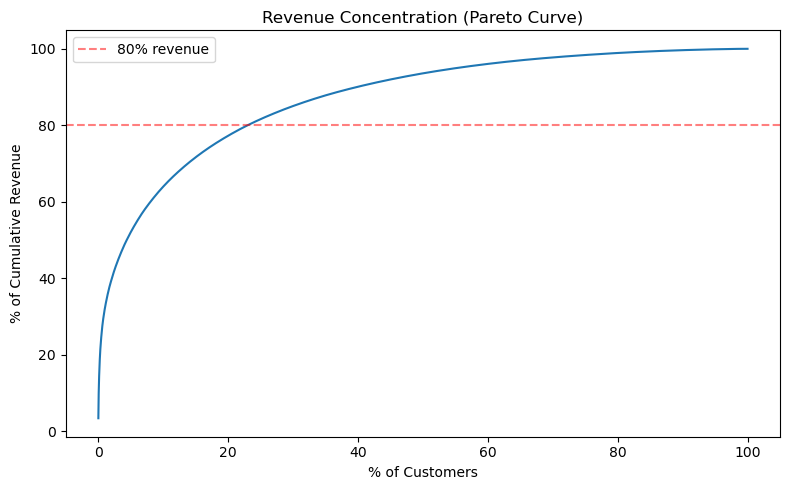

Top 23.0% of customers drive 80% of revenue


In [10]:
customer_revenue = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
cumulative_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100
customer_pct = np.arange(1, len(customer_revenue) + 1) / len(customer_revenue) * 100

plt.figure(figsize=(8, 5))
plt.plot(customer_pct, cumulative_pct)
plt.axhline(y=80, color='r', linestyle='--', alpha=0.5, label='80% revenue')
plt.xlabel('% of Customers')
plt.ylabel('% of Cumulative Revenue')
plt.title('Revenue Concentration (Pareto Curve)')
plt.legend()
plt.tight_layout()
plt.show()

# Find the exact % of customers driving 80% of revenue
idx = np.searchsorted(cumulative_pct.values, 80)
print(f"Top {customer_pct[idx]:.1f}% of customers drive 80% of revenue")


Top 23% of customers drive 80% of total revenue. This confirms extreme revenue concentration and is a key motivation for segmentation — a one-size-fits-all marketing strategy would waste resources on the 77% of low-value customers while under-investing in the top 23% who generate most of the revenue.